# Fake News Detection -- Project Walkthrough

A narrative tour of the full pipeline: dataset, cleaning, feature engineering, and final model results. This notebook is for **viewing and reviewing** the project; it reads already-generated data/results rather than re-running the (slow) heavy steps like Word2Vec training or Random Forest tuning. For hands-on model testing, see `02_model_inference_and_checking.ipynb`.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from IPython.display import Image, display

DATA_DIR = Path('../data')
REPORTS_DIR = Path('../reports')
FIG_DIR = REPORTS_DIR / 'figures'

pd.set_option('display.max_colwidth', 80)

## 2. Dataset Overview

Loads the cleaned dataset (output of `src/day1_load_data.py` + `src/day2_clean_tokenize.py`). Run those scripts first if `combined_cleaned.csv` doesn't exist yet.

In [2]:
df = pd.read_csv(DATA_DIR / 'combined_cleaned.csv')
print(f'Shape: {df.shape}')
print(f'Class balance: {df["label"].value_counts(normalize=True).round(3).to_dict()}  (0=Real, 1=Fake)')
df[['title', 'label', 'text_token_count']].head(10)

Shape: (38604, 8)
Class balance: {0: 0.549, 1: 0.451}  (0=Real, 1=Fake)


,title,label,text_token_count
0,ART CONTEST WINNER Disqualified for Being a Trump Supporter…What Happened to...,1,188
1,"Iranian foreign minister ""unmoved by threats"" from U.S",0,98
2,New York passes emergency spending plan to avoid shutdown,0,304
3,"Factbox: U.S. lawmaker, others in hospital after shooting at baseball practice",0,200
4,"Pence puts North Korea on notice not to test U.S. resolve, citing Syria strike",0,50
5,CNN REPORTER: Victims at Las Vegas Concert Were Likely Trump Supporters [VIDEO],1,185
6,George H. W. Bush Writes Letter Showing Trump How To NOT Be A Corrupt Presi...,1,321
7,President Obama Says He Believes The Affordable Care Act Will Survive Trump...,1,177
8,Police Say Fire At DC Memorial For Muslim Teen Was ‘Not A Hate Crime’,1,207
9,NATO chief says Europe has interest in helping Afghanistan,0,213


### Before / After Cleaning Example

Shows the effect of manual cleaning, tokenization, stopword removal, and the Reuters-dateline strip (see Section 2.3 of the report for why that mattered).

In [3]:
sample = df.iloc[0]
print('RAW TEXT:\n', sample['text'][:300], '\n')
print('CLEANED TEXT:\n', sample['text_clean'][:300])

RAW TEXT:
 So now if you enter a contest, you need to worry about your political affiliation if you re a Republican? The left continues to show that they are the most intolerant of anyone who s across the aisle from them. It s getting uglier and uglier out there. What happened to the  accepting  leftists who c 

CLEANED TEXT:
 enter contest need worry political affiliation republican left continues show intolerant anyone across aisle getting uglier uglier happened accepting leftists claim people suggestion please message gypsy twitter instagram also good idea contact kat von beauty light social media wichita eagle reporte


## 3. Exploratory Data Analysis

Figures generated by `src/day3_eda.py`.

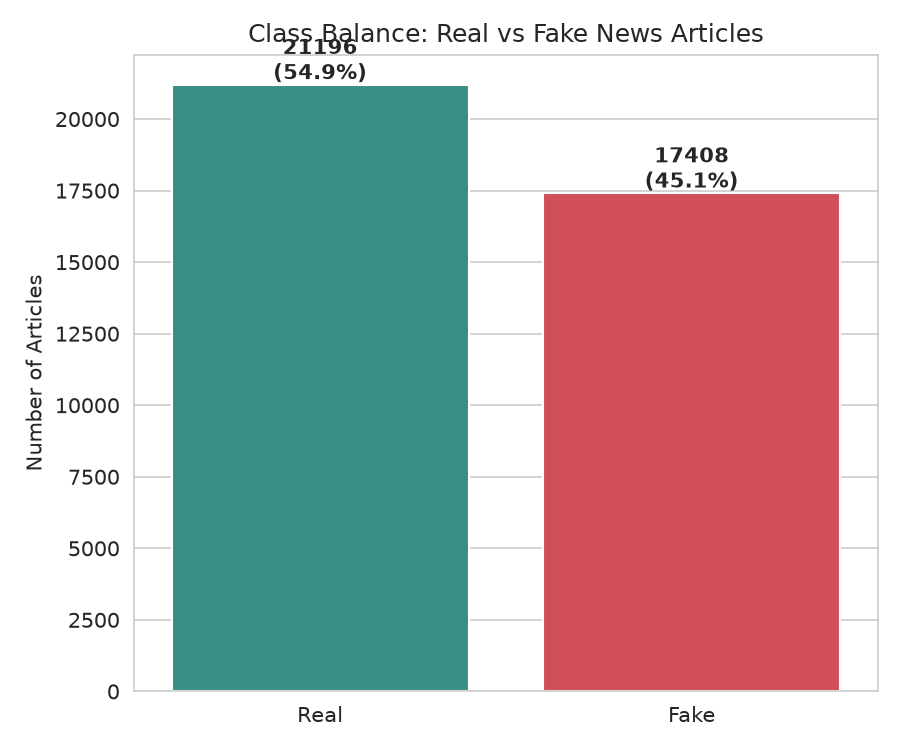

In [4]:
display(Image(filename=str(FIG_DIR / '01_class_balance.png')))

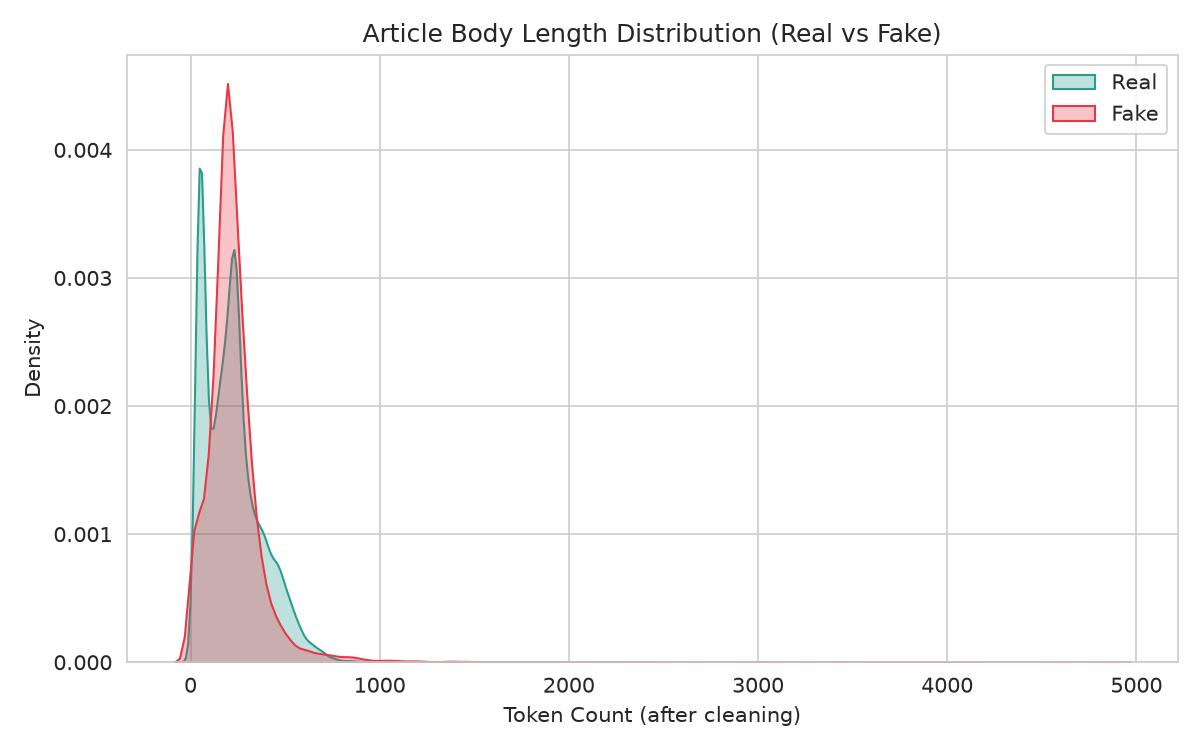

In [5]:
display(Image(filename=str(FIG_DIR / '02_article_length_distribution.png')))

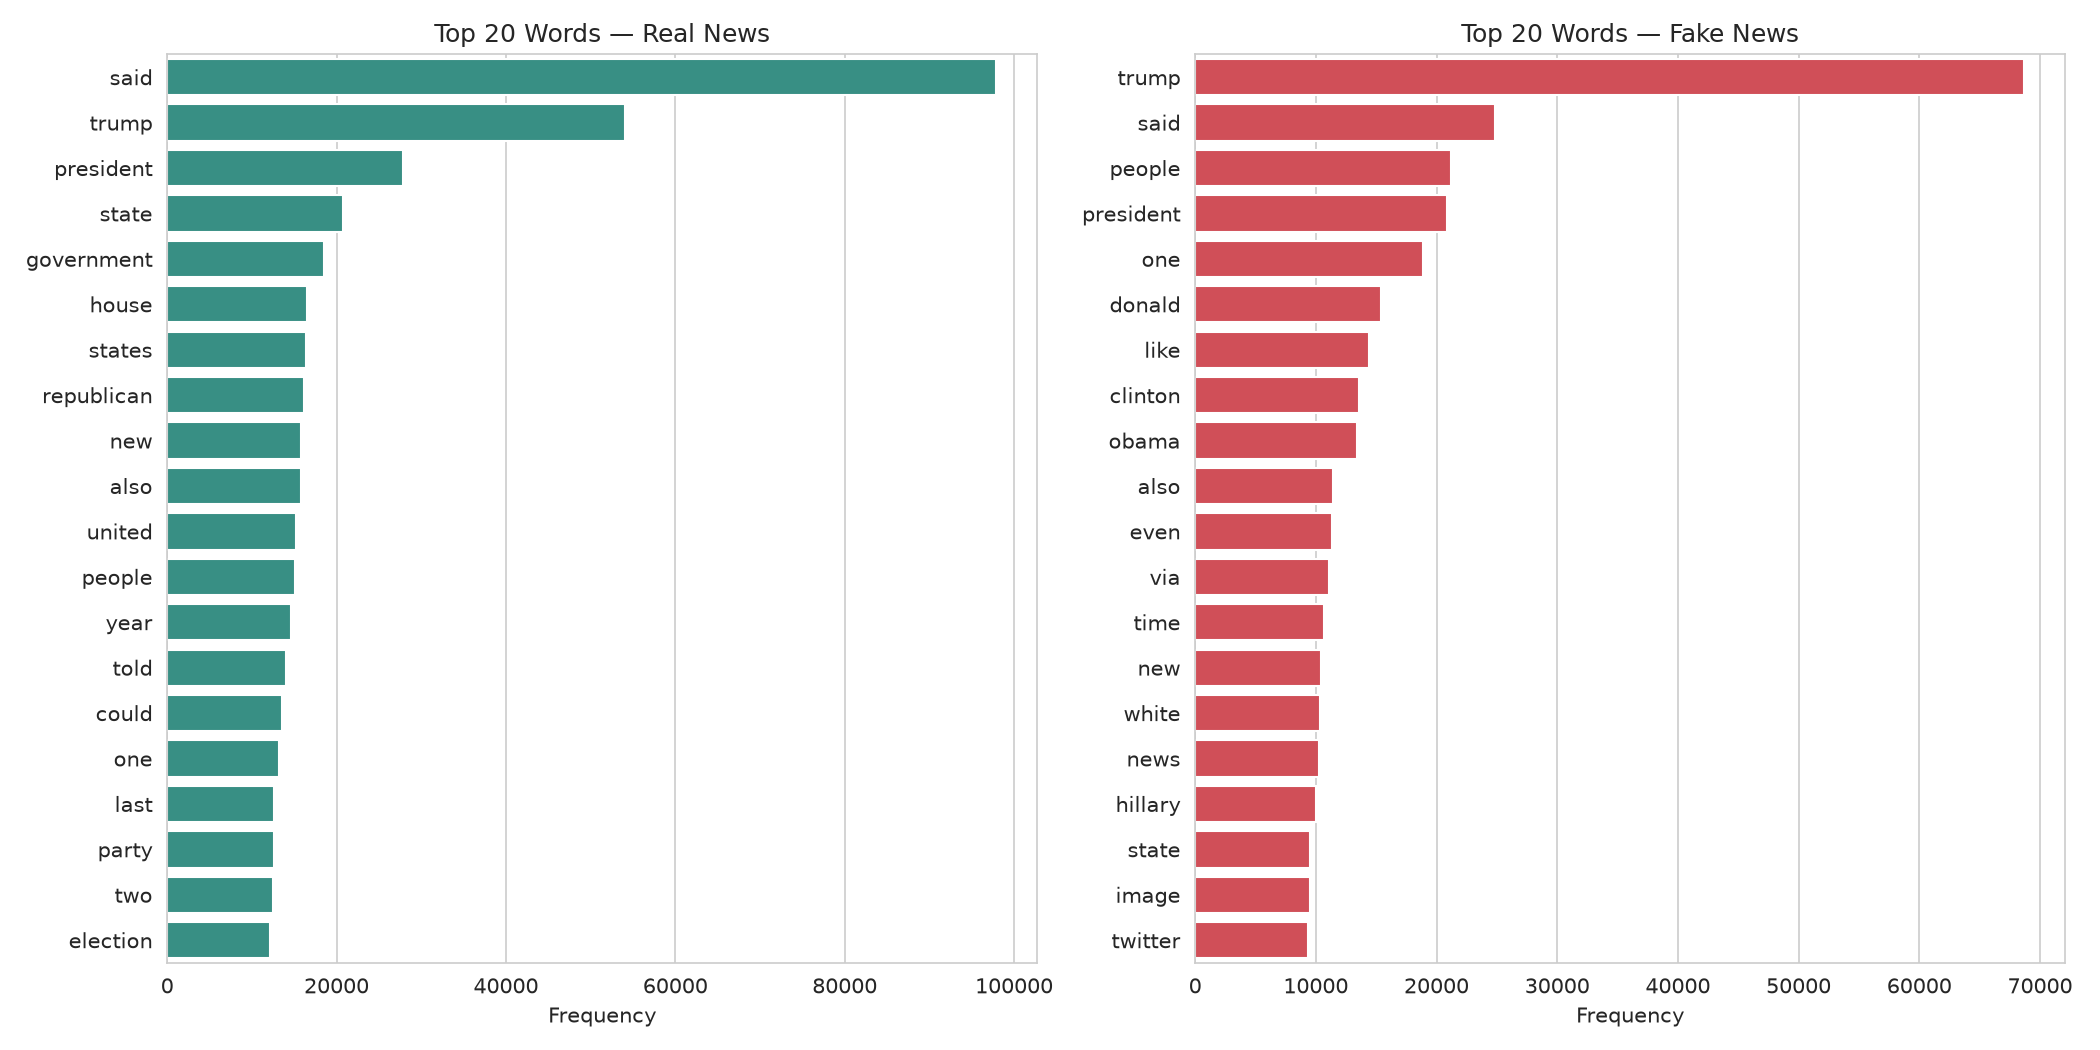

In [6]:
display(Image(filename=str(FIG_DIR / '04_top_words_by_label.png')))

## 4. Feature Engineering Summary

Three feature representations were built (Bag-of-Words, TF-IDF, Word2Vec embeddings), all from scratch -- see `src/day4_bag_of_words.py`, `day5_tfidf.py`, `day6_embeddings.py`. `day7_consolidate_features.py` validates they're all row-aligned with the labels.

In [7]:
import sys
sys.path.insert(0, '../src')
from day7_consolidate_features import load_feature_set, FEATURE_FILES

for name in FEATURE_FILES:
    X_train, X_test, y_train, y_test = load_feature_set(name)
    print(f'{name:12s} train={X_train.shape}  test={X_test.shape}')

bow          train=(30883, 5000)  test=(7721, 5000)
tfidf        train=(30883, 5000)  test=(7721, 5000)
embeddings   train=(30883, 100)  test=(7721, 100)


## 5. Final Model Comparison

Consolidated results from all four models across all three feature sets (`src/day14_consolidate_results.py`).

In [8]:
comparison = pd.read_csv(REPORTS_DIR / 'final_model_comparison.csv')
comparison

,Model,Type,Feature Set,Test Accuracy,Test Precision,Test Recall,Test F1,CV/Robustness Acc Mean,CV/Robustness Acc Std
0,KNN,Non-Parametric,embeddings,94.59,96.42,91.38,93.84,94.26,0.29
1,Logistic Regression,Parametric,tfidf,98.36,98.89,97.44,98.16,98.10,0.11
2,Random Forest,Ensemble,tfidf,98.01,99.29,96.27,97.75,97.55,0.18
3,Neural Network,Deep Learning,tfidf,98.17,98.21,97.73,97.97,98.21,0.04


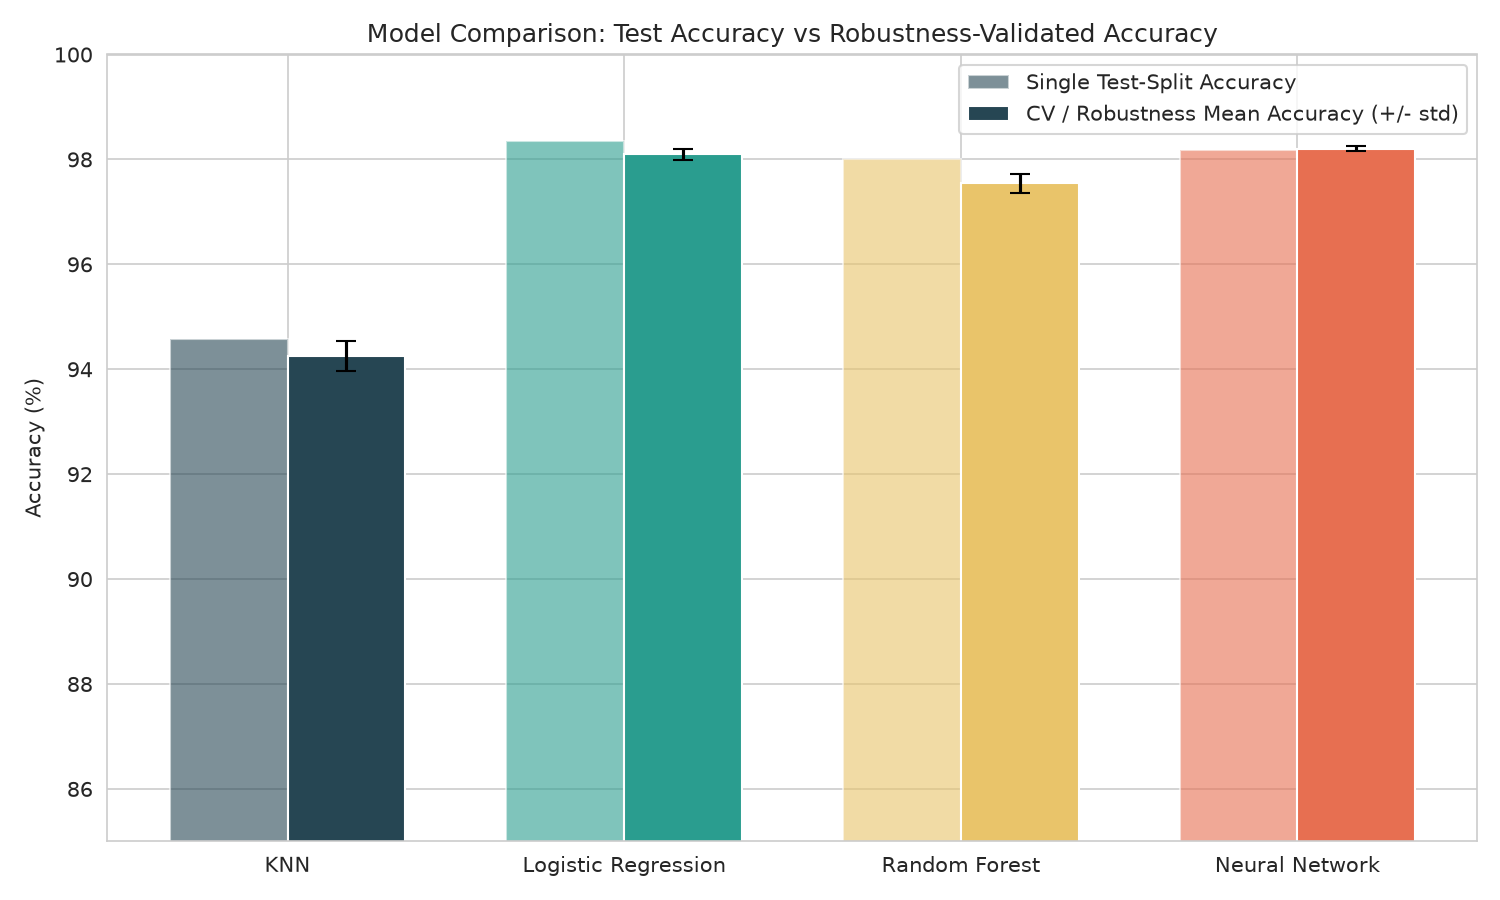

In [9]:
display(Image(filename=str(FIG_DIR / '05_final_model_comparison.png')))

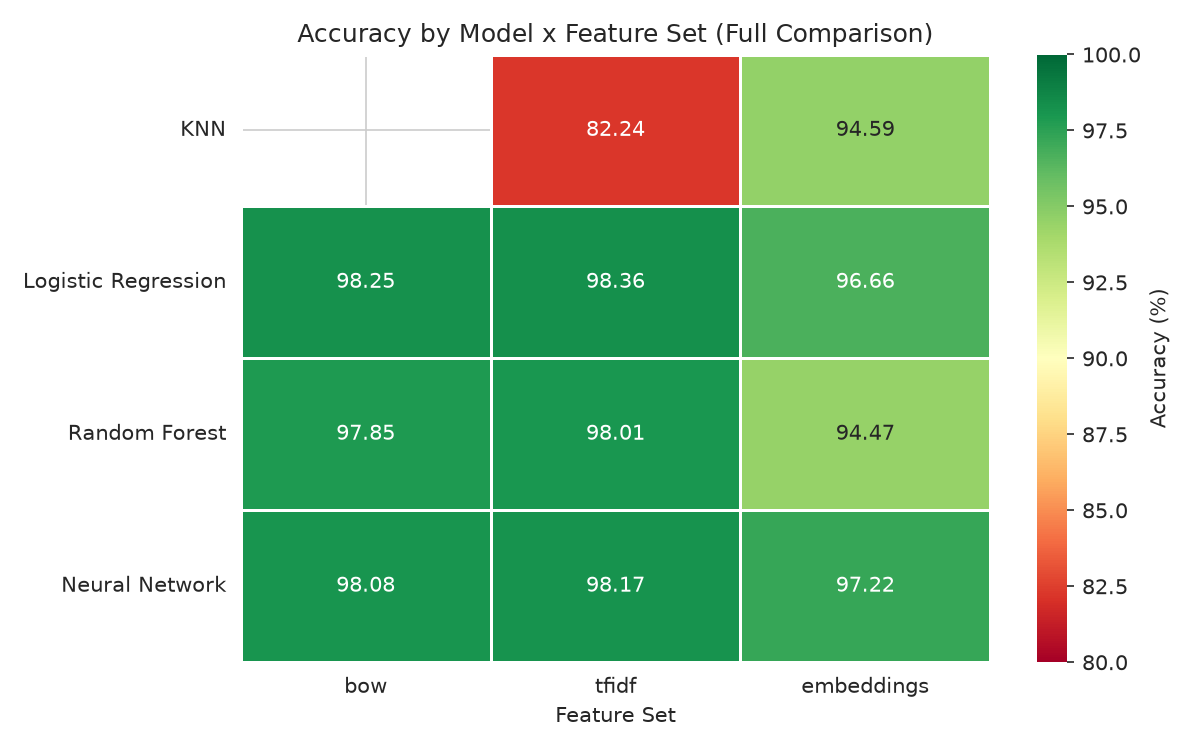

In [10]:
display(Image(filename=str(FIG_DIR / '09_model_feature_heatmap.png')))

## 6. ROC and Precision-Recall Curves

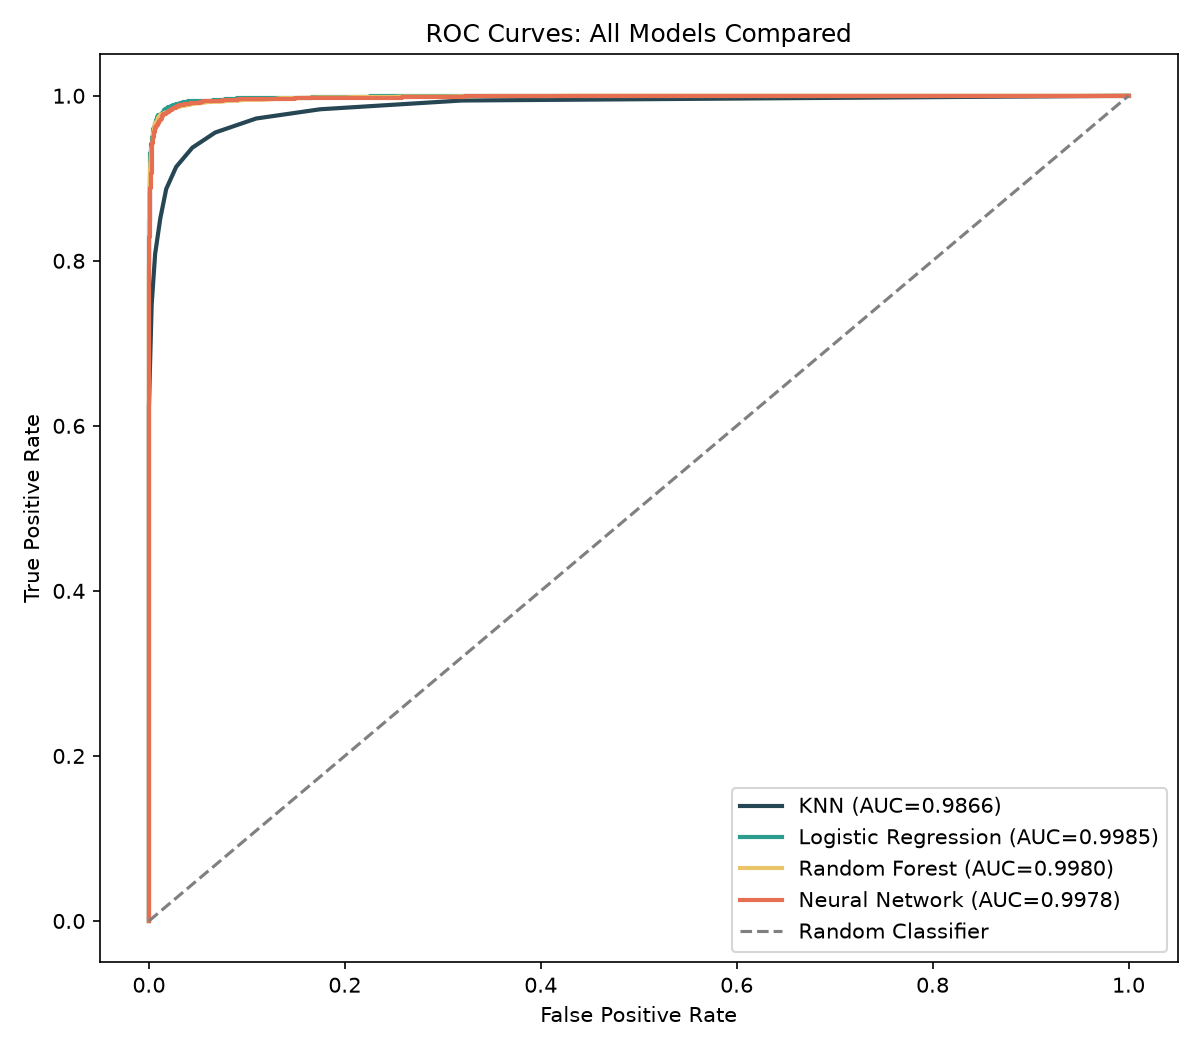

In [11]:
display(Image(filename=str(FIG_DIR / '07_roc_curves.png')))

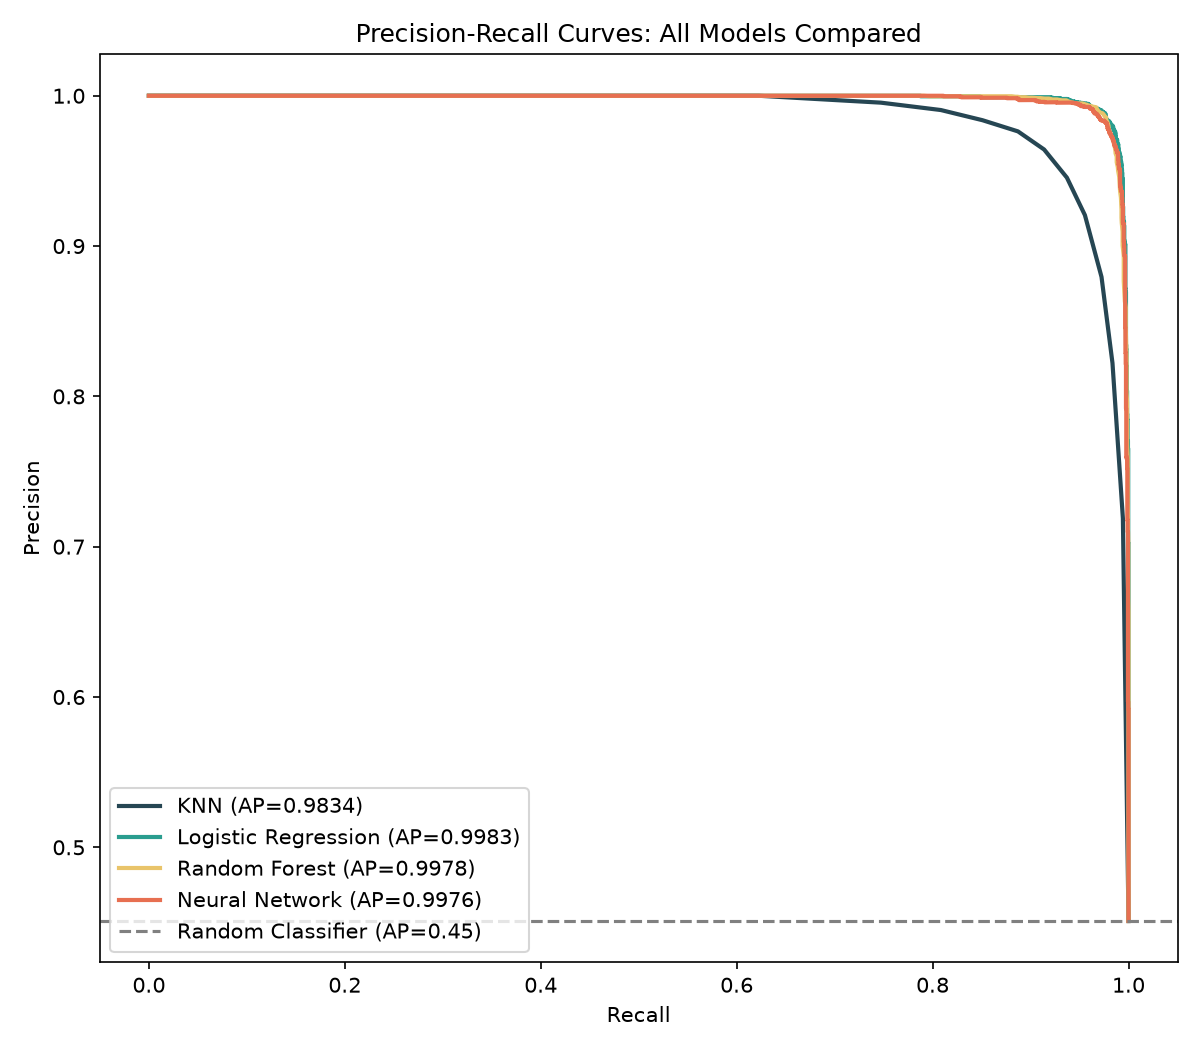

In [12]:
display(Image(filename=str(FIG_DIR / '08_precision_recall_curves.png')))

## 7. Cross-Validation / Robustness

Confirms the single-split results above aren't a lucky/unlucky train-test split.

In [13]:
with open(REPORTS_DIR / 'day12_cv_tuning_results.json') as f:
    cv_results = json.load(f)

for model_name, res in cv_results.items():
    best = res.get('best', res)
    print(f"{model_name:12s} acc={best.get('accuracy_mean', '?')} +/- {best.get('accuracy_std', '?')}")

with open(REPORTS_DIR / 'day13_nn_robustness_results.json') as f:
    nn_robust = json.load(f)
print(f"neural_network  acc={nn_robust['summary']['accuracy']['mean']:.4f} "
      f"+/- {nn_robust['summary']['accuracy']['std']:.4f}  (5 seeds, {nn_robust['feature_set']})")

knn          acc=0.9425571923590856 +/- 0.0028591231625101636
logreg       acc=0.9809603683982282 +/- 0.0010774057992663825
rf           acc=0.9754881523972013 +/- 0.0018245442440402646
neural_network  acc=0.9821 +/- 0.0004  (5 seeds, tfidf)


## 8. Key Takeaways

1. **Logistic Regression** (parametric) was the best overall model -- simplest model, best result.
2. **KNN** (non-parametric) swung from 82% to 95% accuracy purely from changing feature representation -- a direct demonstration of the curse of dimensionality.
3. Two feature-leakage issues (`subject` category, Reuters dateline) were caught during EDA and corrected before modeling -- without this, reported accuracy would have been an artifact, not a real result.
4. The top predictive words reflect **formatting/sourcing style**, not fact-checking -- an important scope limitation, detailed in the full report's Discussion section.

See `reports/Fake_News_Detection_IEEE_Report.docx` for the complete writeup, and `02_model_inference_and_checking.ipynb` to test the model on your own text.